In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster(n_workers=4, threads_per_worker=1,  memory_limit='6GB')
client = Client(cluster)

In [2]:
from tropical_cyclones import TCs, multi_plot, plot_trajectories
from aqua.core.util import load_yaml

config = load_yaml('/home/mccorda/work/tc_analysis2/config_tcs_monthlystitch.yaml')

/work/users/mccorda/miniforge3/envs/aqua-diagnostics/lib/python3.12/site-packages/intake_esm/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [3]:
# initialise tropical class with streaming options
tropical = TCs(tdict=config, streaming=True,
                stream_step=config['stream']['streamstep'],
                stream_startdate=config['time']['startdate'],
                paths=config['paths'],
                loglevel=config['setup']['loglevel'],
                orography=True,
                nproc=1)

2026-02-23 14:24:09 :: TCs :: WARNING  -> Model ERA5 - Exp: era5
2026-02-23 14:24:09 :: TCs :: WARNING  -> Initialised streaming for 1D days starting on 1979-01-01 00:00:00
2026-02-23 14:24:09 :: ConfigPath :: DEBUG    -> AQUA installation found in /home/mccorda/.aqua
2026-02-23 14:24:09 :: ConfigPath :: DEBUG    -> Configuration file found in /home/mccorda/.aqua/config-aqua.yaml
2026-02-23 14:24:09 :: ConfigPath :: DEBUG    -> Catalog found in /home/mccorda/.aqua/config-aqua.yaml file are my_catalogs
2026-02-23 14:24:09 :: ConfigPath :: DEBUG    -> Available catalogs are ['my_catalogs']
2026-02-23 14:24:09 :: ConfigPath :: DEBUG    -> Default catalog will be my_catalogs
2026-02-23 14:24:09 :: ConfigPath :: DEBUG    -> Catalog file is /home/mccorda/.aqua/catalogs/my_catalogs/catalog.yaml
2026-02-23 14:24:09 :: ConfigPath :: DEBUG    -> Machine file is /home/mccorda/.aqua/catalogs/my_catalogs/machine.yaml
2026-02-23 14:24:09 :: ConfigPath :: DEBUG    -> Machine found in configuration fi

In [5]:
# ===========================================
# 1. SETUP - Parametri da config
# ===========================================
import os
from glob import glob
from datetime import datetime

trackdir = config['paths']['trackdir']
tmpdir = config['paths']['tmpdir']
era5_dir = "/work/users/mccorda/data"
start_date = datetime.strptime(config['time']['startdate'], "%Y%m%d")
end_date   = datetime.strptime(config['time']['enddate'], "%Y%m%d")

In [6]:
# ===========================================
# 2. SELEZIONE FILE - Trova i file tempest_track nel range di date
# ===========================================
all_files = sorted(glob(os.path.join(trackdir, "tempest_track_*.txt")))
filenames = []
for f in all_files:
    base = os.path.basename(f)
    try:
        parts = base.replace("tempest_track_", "").replace(".txt", "").split("-")
        start_f = datetime.strptime(parts[0], "%Y%m%d")
        end_f = datetime.strptime(parts[1], "%Y%m%d")
        if end_f >= start_date and start_f <= end_date:
            filenames.append(f)
    except:
        pass

print(f"[INFO] File selezionati: {len(filenames)}")

[INFO] File selezionati: 444


In [8]:
# ===========================================
# 3. MERGE FILE - CON STORM_ID UNICI
# ===========================================
os.makedirs(tmpdir, exist_ok=True)
tot_file = os.path.join(tmpdir, f"tempest_tracks_tot_{config['time']['startdate']}_{config['time']['enddate']}.txt")

global_storm_id = 0  # Contatore globale

with open(tot_file, 'w') as output_file:
    output_file.write("track_id year month day hour i j lon lat slp wind zs\n")
    
    for fname in filenames:
        with open(fname, 'r') as infile:
            lines = infile.readlines()
            
            if len(lines) == 0:
                print(f"[WARNING] File vuoto: {fname}")
                continue
            
            # Mappa storm_id locali -> storm_id globali
            local_to_global = {}
            
            for line in lines[1:]:  # Skippa header
                clean = line.replace(',', '').strip()
                if not clean:
                    continue
                parts = clean.split()
                if len(parts) != 12:
                    continue
                
                local_id = parts[0]
                
                # Assegna nuovo ID globale se è la prima volta che vediamo questo local_id
                if local_id not in local_to_global:
                    local_to_global[local_id] = str(global_storm_id)
                    global_storm_id += 1
                
                # Sostituisci con ID globale
                parts[0] = local_to_global[local_id]
                output_file.write(" ".join(parts) + "\n")

print(f"[INFO] File totale creato: {tot_file}")
print(f"[INFO] Totale storm unici: {global_storm_id}")

[INFO] File totale creato: /work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19790101_20150106.txt
[INFO] Totale storm unici: 2510


In [9]:
# ===========================================
# 4. FILTRO STJ - Applica il filtro 
# ===========================================
import sys
import os

# ============================================================
#   STJ Filter (versione adattata ai dati 250 hPa)
#   Basato sul metodo di Bourdin et al. (2022)
#   Versione semplificata: climatologia mensile, soglie su U e V,
#   jet-lat trovato come massimo del profilo del wind speed.
#   FIX: gestisce sia spazi che virgole come separatori
# ============================================================

# Path TCs_filter.py
custom_path = '/home/mccorda/work/AQUA-diagnostics/frontier-diagnostics/tropical_cyclones/tropical_cyclones/tools/'
if custom_path not in sys.path:
    sys.path.insert(0, custom_path)

# Import the filter
from TCs_filter import filter_STJ_Bourdin250_monthly

# Apply the filter to tot_file
filtered_file, jet_lat_NH, jet_lat_SH = filter_STJ_Bourdin250_monthly(
    trajfile=tot_file,
    era5_dir=era5_dir,
    buffer_deg=8.0,  # buffer zone in gradi
    lat_min=10,      # limite equatoriale per jet search
    lat_max=50       # limite polare per jet search
)

print(f"\n✓ File filtrato creato: {filtered_file}")

[INFO] STJ filter (Bourdin 250 hPa monthly) applied to /work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19790101_20150106.txt

STJ FILTER - Bourdin et al. (2022) method
Input file: /work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19790101_20150106.txt
Buffer zone: 8.0° equatorward of jet
Jet detection: U>=25 m/s, V>=25 m/s
Data period: 1979–2014 (36 years)

Computing ERA5 250 hPa monthly climatology...
  Loading 1979 ERA5 250 hPa...
  Loading 1980 ERA5 250 hPa...
  Loading 1981 ERA5 250 hPa...
  Loading 1982 ERA5 250 hPa...
  Loading 1983 ERA5 250 hPa...
  Loading 1984 ERA5 250 hPa...
  Loading 1985 ERA5 250 hPa...
  Loading 1986 ERA5 250 hPa...
  Loading 1987 ERA5 250 hPa...
  Loading 1988 ERA5 250 hPa...
  Loading 1989 ERA5 250 hPa...
  Loading 1990 ERA5 250 hPa...
  Loading 1991 ERA5 250 hPa...
  Loading 1992 ERA5 250 hPa...
  Loading 1993 ERA5 250 hPa...
  Loading 1994 ERA5 250 hPa...
  Loading 1995 ERA5 250 hPa...
  Loading 1996 ERA5 250 hPa

In [10]:
# ===========================================
# 5: load data (memory)
# ===========================================
import sys
import os

tools_path = '/home/mccorda/work/AQUA-diagnostics/frontier-diagnostics/tropical_cyclones/tropical_cyclones/tools/'
plots_path = '/home/mccorda/work/AQUA-diagnostics/frontier-diagnostics/tropical_cyclones/tropical_cyclones/plots/'

if tools_path not in sys.path:
    sys.path.insert(0, tools_path)
if plots_path not in sys.path:
    sys.path.insert(0, plots_path)

In [11]:
from tc_data_manager import TCDataManager
from plotting_TCs_custom_memory import *  # import all the plotting functions

# CARICA DATI UNA VOLTA SOLA
tc_data = TCDataManager(filtered_file)
tc_data.summary()


LOADING TC DATA INTO MEMORY
Source: /work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19790101_20150106_filtered_STJ_Bourdin250_monthly.txt
  Parsed 57,216 observations from file
  Converting to numpy arrays...
  Building trajectory list...
✓ Data loaded successfully!
  Observations: 57,216
  Storms: 2484


TC DATA SUMMARY
Source file: /work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19790101_20150106_filtered_STJ_Bourdin250_monthly.txt
Total observations: 57,216
Total storms: 2484

Time period:
  Start: 1979-01
  End: 2014-12
  Duration: 432 months

Data ranges:
  SLP: 92693.3 - 101968.6 Pa
  Wind: 2.2 - 33.6 m/s
  Latitude: -67.5° to 66.5°
  Longitude: 0.0° to 359.0°

Memory usage:
  Total: 5.67 MB

Trajectory structure:
  Type: LIST (not dict)
  Length: 2484
  First storm ID: '0'
  Last storm ID: '2509'



In [13]:
tc_data.trajectories[54]

{'id': np.str_('55'),
 'lon': array([128., 127., 126., 125., 123., 122., 121., 119., 117., 115., 114.,
        112., 110., 109., 107., 108., 108., 106., 105., 104., 103., 100.]),
 'lat': array([-11.5, -11.5, -12.5, -12.5, -13.5, -14.5, -14.5, -15.5, -15.5,
        -15.5, -16.5, -16.5, -16.5, -16.5, -17.5, -16.5, -16.5, -17.5,
        -18.5, -20.5, -21.5, -22.5]),
 'slp': array([100313.4 , 100274.4 , 100077.9 , 100123.4 ,  99943.92,  99898.45,
         99722.28,  99366.96,  99291.84,  99006.77,  98944.85,  98499.44,
         98606.55,  98398.82,  98519.93,  98170.34,  98778.27,  99395.58,
         99429.12,  99855.44,  99871.41,  99716.51]),
 'wind': array([11.76361, 11.09445, 13.01943, 12.4389 , 13.45928, 14.27082,
        15.32854, 16.18657, 17.50256, 18.38978, 17.19614, 20.05213,
        19.62592, 19.07149, 20.04876, 23.94026, 21.80008, 17.9063 ,
        17.0011 , 14.82842, 14.71046, 16.36671]),
 'year': array([1980, 1980, 1980, 1980, 1980, 1980, 1980, 1980, 1980, 1980, 1980,
       

Using data from memory (fast)
✓ PDF saved to: /work/users/mccorda/tc_analysis2/Figures/tracks_ERA5_era5_19790101_20150106.pdf


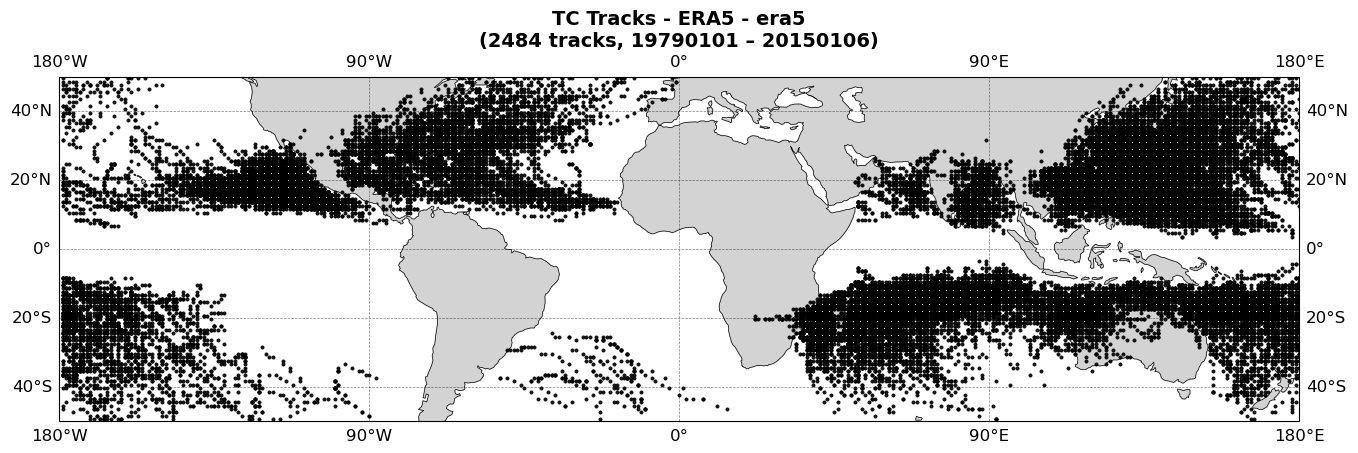

✓ NetCDF saved to: /work/users/mccorda/tc_analysis2/Figures/tracks_ERA5_era5_19790101_20150106.nc


In [13]:
# ===========================================
# 6: plots using tc_data in memory
# ===========================================
plot_trajectories_direct(tc_data, config)   

Using data from memory (fast)
Plotting all 2484 storms colored by category
Plotting storms ordered: weak (background) → strong (foreground)
✓ PDF saved to: /work/users/mccorda/tc_analysis2/Figures/tracks_colored_category_ERA5_era5_19790101_20150106.pdf


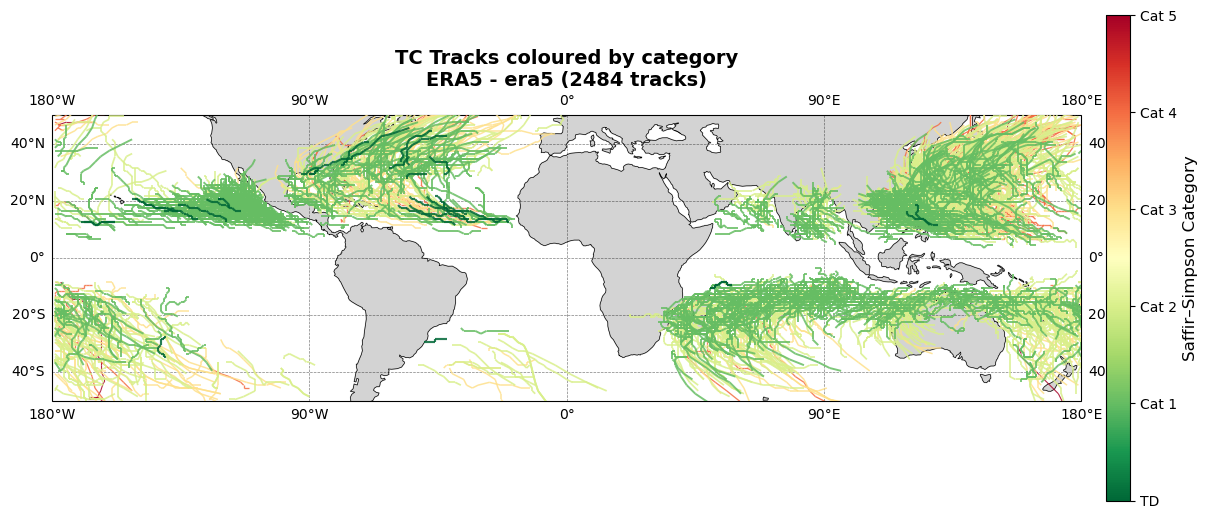

✓ NetCDF saved to: /work/users/mccorda/tc_analysis2/Figures/tracks_colored_category_ERA5_era5_19790101_20150106.nc


In [14]:
# OPZIONE 1: Tutte le traiettorie colorate per categoria
#plot_trajectories_colored(tc_data, config, color_by='category')
plot_trajectories_colored(tc_data, config)  
# → Salva: tracks_colored_category_MODEL_EXP_DATE.pdf/nc

Using data from memory (fast)
Filtering for Cat 4 (945–959)...
✓ Found 100 trajectories for Cat 4 (945–959)


/work/users/mccorda/miniforge3/envs/aqua-diagnostics/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/work/users/mccorda/miniforge3/envs/aqua-diagnostics/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/work/users/mccorda/miniforge3/envs/aqua-diagnostics/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/work/users/mccorda/miniforge3/envs/aqua-diagnostics/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/work/users/mccorda/miniforge3/envs/aqua-diagnostics

✓ PDF saved to: /work/users/mccorda/tc_analysis2/Figures/tracks_cat4_ERA5_era5_19790101_20150106.pdf


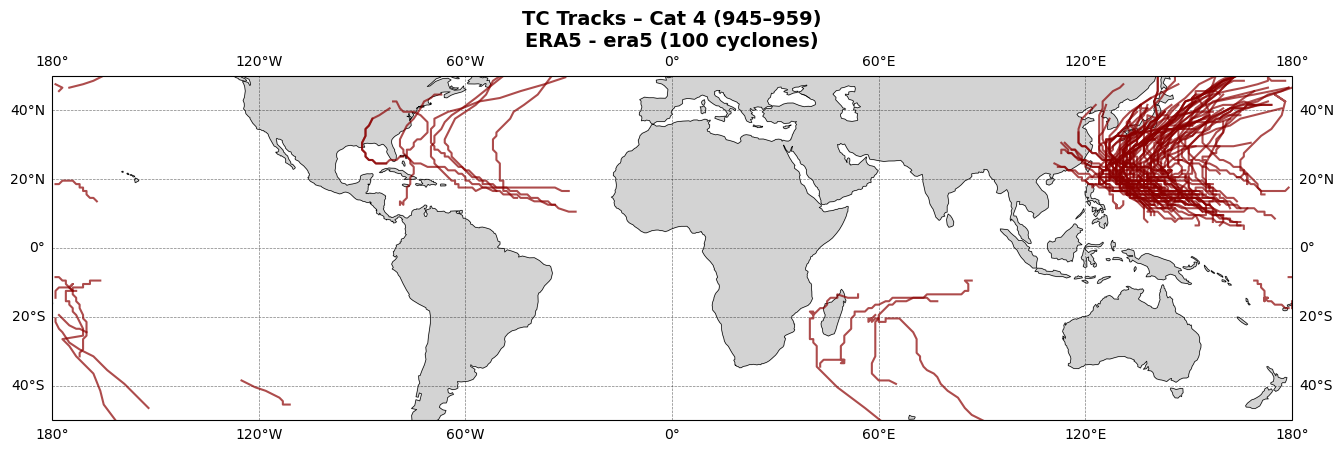

✓ NetCDF saved to: /work/users/mccorda/tc_analysis2/Figures/tracks_cat4_ERA5_era5_19790101_20150106.nc


In [16]:
# OPZIONE 2: Solo Cat 4
plot_trajectories_colored(tc_data, config, category=4)
# → Salva: tracks_cat4_MODEL_EXP_DATE.pdf/nc

Using data from memory (fast)
Filtering for Cat 5 (<945)...
✓ Found 7 trajectories for Cat 5 (<945)


/work/users/mccorda/miniforge3/envs/aqua-diagnostics/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


✓ PDF saved to: /work/users/mccorda/tc_analysis2/Figures/tracks_cat5_ERA5_era5_19790101_20150106.pdf


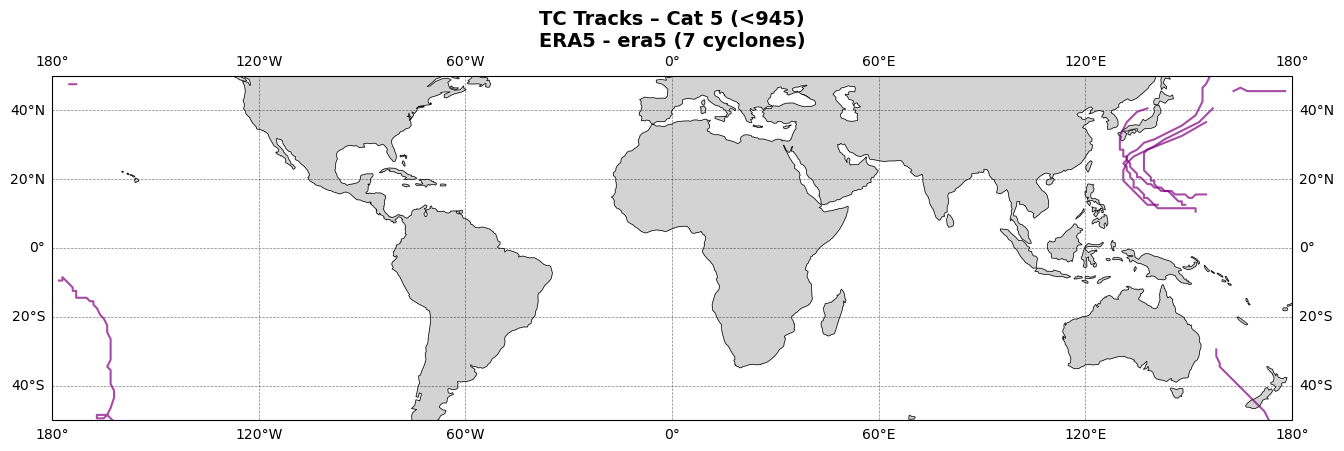

✓ NetCDF saved to: /work/users/mccorda/tc_analysis2/Figures/tracks_cat5_ERA5_era5_19790101_20150106.nc


In [17]:
# OPZIONE 3: Solo Cat 5
plot_trajectories_colored(tc_data, config, category=5)
# → Salva: tracks_cat5_MODEL_EXP_DATE.pdf/nc

Using data from memory (fast)
Total TC observation points: 39,410
Computing KDE...
✓ Plot saved: /work/users/mccorda/tc_analysis2/Figures/density_scatter_ERA5_era5_19790101_20050106.pdf


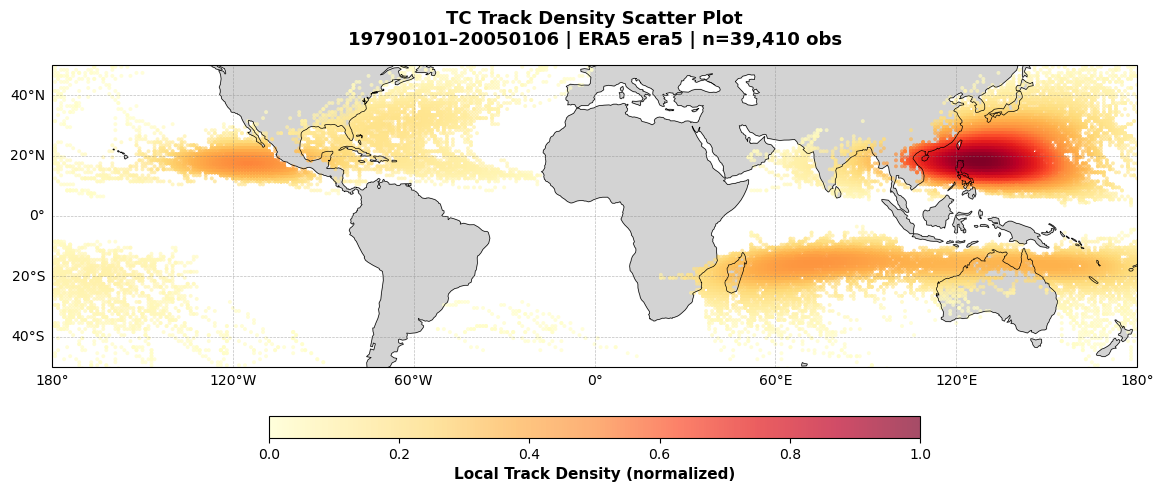

In [11]:
plot_density_scatter(tc_data, config) 

Using data from memory (fast)
Total TC observation points: 57,216
Time period: 433 months
Data range: 0.0023 - 0.14 transits/month
Colorbar range: 0.0100 - 0.15
Colorbar boundaries: [0.         0.01253163 0.01570418 0.0196799  0.02466212 0.03090566
 0.03872983 0.0485348  0.06082202 0.07621991 0.09551598 0.11969711
 0.15      ]
✓ PDF saved to: /work/users/mccorda/tc_analysis2/Figures/track_density_grid_ERA5_era5_19790101_20150106.pdf


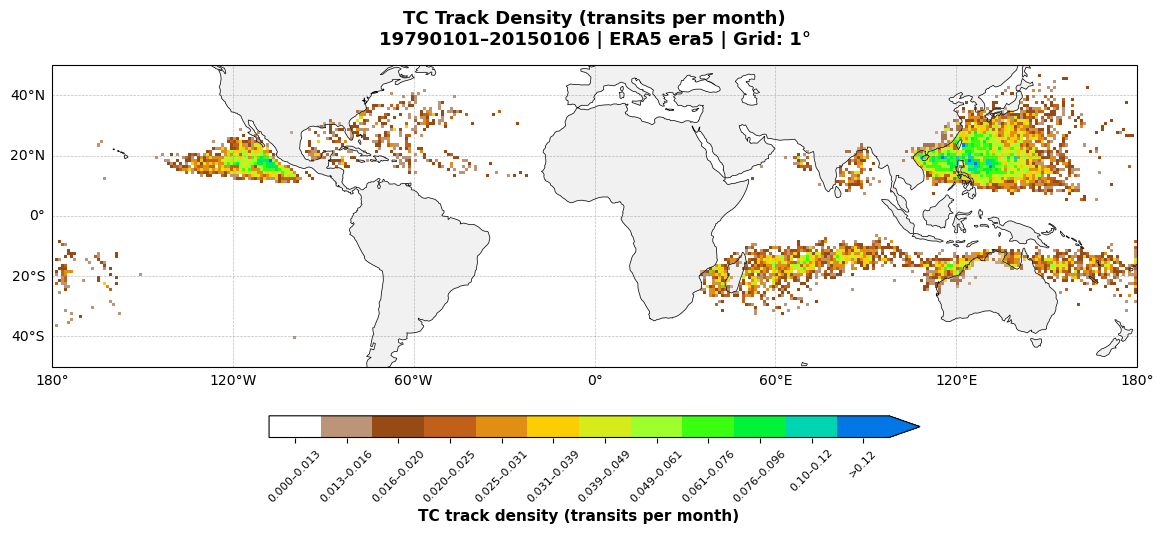

✓ NetCDF saved to: /work/users/mccorda/tc_analysis2/Figures/track_density_grid_ERA5_era5_19790101_20150106.nc
  Grid dimensions: 100 lat × 360 lon
  Data variables: transits_per_month, count, transits_discrete


In [18]:
# Plot di tutti i TC
plot_track_density_grid(tc_data, config, grid_size=1)

Using data from memory (fast)
Filtering for Cat 3 (960–974 hPa) and stronger...
✓ Found 451 storms with peak intensity ≥ Cat 3 (960–974 hPa)
Total TC observation points: 14,871
Time period: 433 months
Data range: 0.0023 - 0.09 transits/month
Colorbar range: 0.0100 - 0.10
Colorbar boundaries: [0.         0.01211528 0.01467799 0.01778279 0.02154435 0.02610157
 0.03162278 0.03831187 0.04641589 0.05623413 0.06812921 0.08254042
 0.1       ]
✓ PDF saved to: /work/users/mccorda/tc_analysis2/Figures/track_density_grid_ERA5_era5_19790101_20150106_cat3plus.pdf


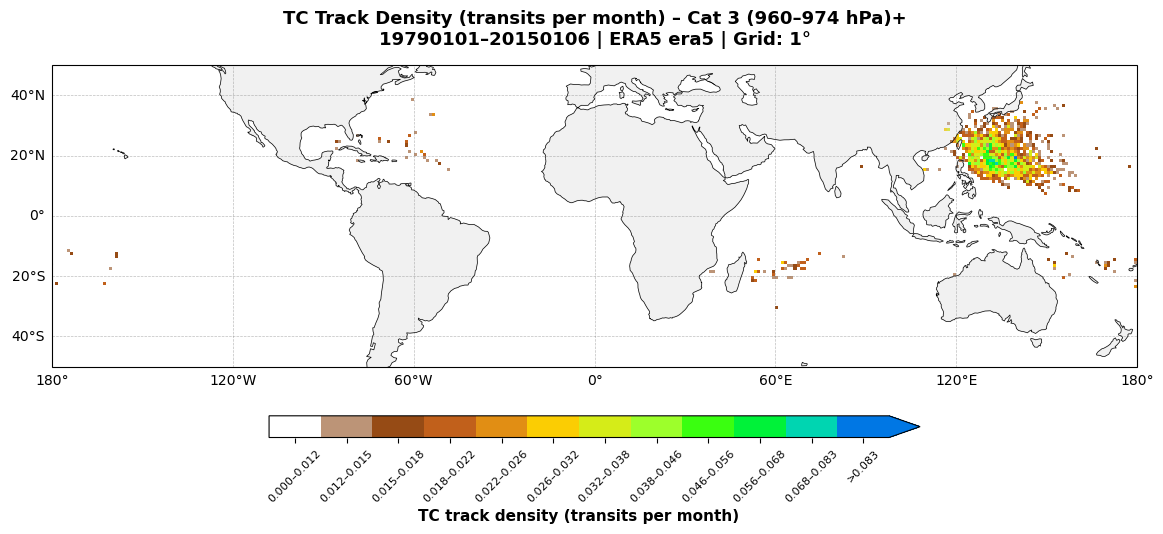

✓ NetCDF saved to: /work/users/mccorda/tc_analysis2/Figures/track_density_grid_ERA5_era5_19790101_20150106_cat3plus.nc
  Grid dimensions: 100 lat × 360 lon
  Data variables: transits_per_month, count, transits_discrete


In [19]:
# Solo Major Hurricanes (Cat 3+)
plot_track_density_grid(tc_data, config, category=3)

Using data from memory (fast)
Filtering for Cat 4 (945–959 hPa) and stronger...
✓ Found 107 storms with peak intensity ≥ Cat 4 (945–959 hPa)
Total TC observation points: 3,972
Time period: 433 months
Data range: 0.0023 - 0.05 transits/month
Colorbar range: 0.0100 - 0.05
Colorbar boundaries: [0.         0.0114353  0.0130766  0.01495349 0.01709976 0.01955409
 0.02236068 0.0255701  0.02924018 0.03343702 0.03823622 0.04372426
 0.05      ]
✓ PDF saved to: /work/users/mccorda/tc_analysis2/Figures/track_density_grid_ERA5_era5_19790101_20150106_cat4plus.pdf


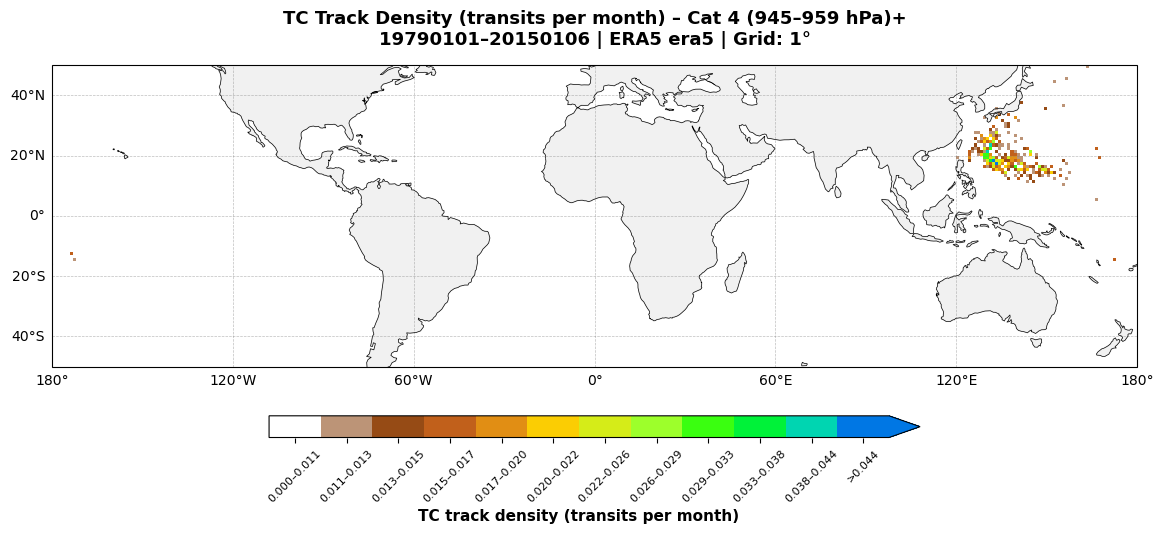

✓ NetCDF saved to: /work/users/mccorda/tc_analysis2/Figures/track_density_grid_ERA5_era5_19790101_20150106_cat4plus.nc
  Grid dimensions: 100 lat × 360 lon
  Data variables: transits_per_month, count, transits_discrete


In [20]:
# Cat 4 plus
plot_track_density_grid(tc_data, config, grid_size=1, category=4)

Using data from memory (fast)

Points per category:
  Cat 0: 5,381 points
  Cat 1: 35,550 points
  Cat 2: 12,309 points
  Cat 3: 3,448 points
  Cat 4: 505 points
  Cat 5: 23 points
✓ 6-panel plot saved: /work/users/mccorda/tc_analysis2/Figures/density_scatter_by_category_ERA5_era5_19790101_20150106.pdf


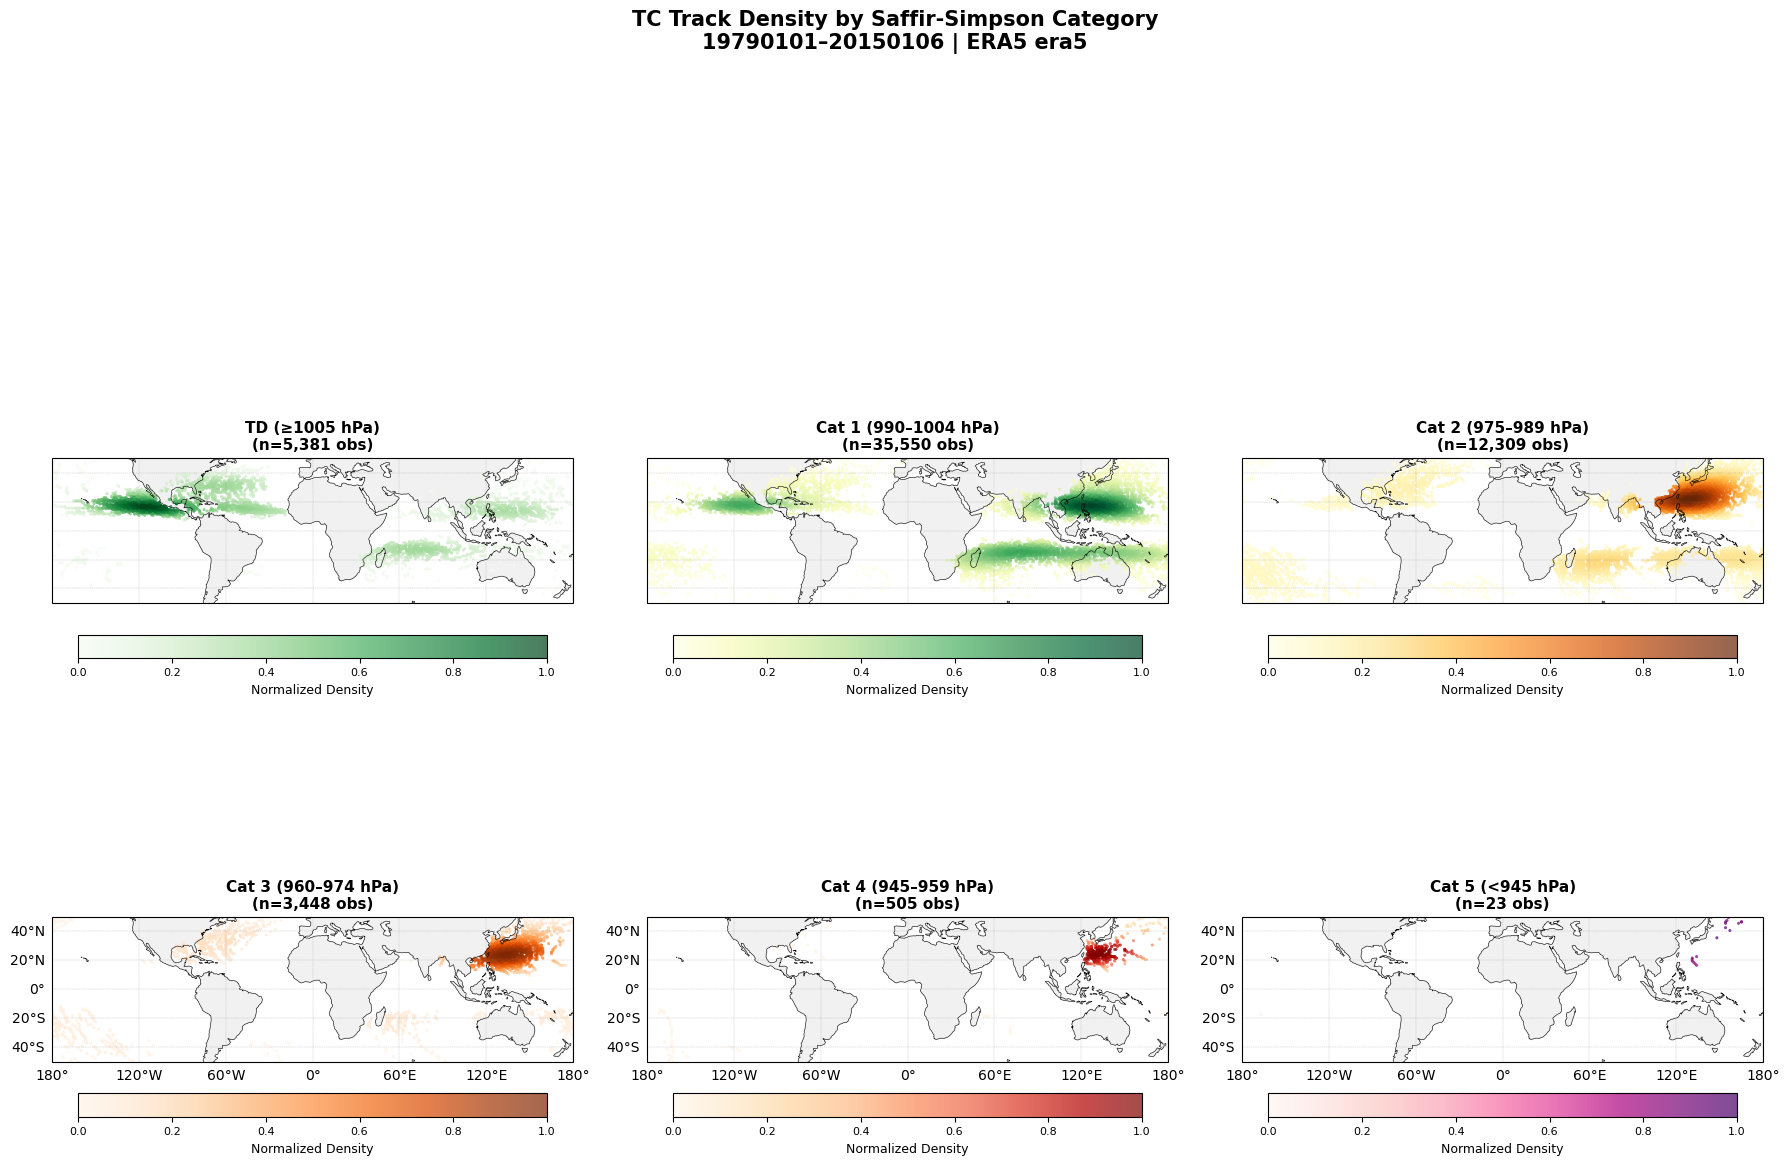

In [21]:
plot_density_scatter_by_category(tc_data, config) 

Computing TC duration statistics from memory...
Using data from memory (fast)

TC DURATION STATISTICS
Total cyclones: 2484
Mean duration: 5.5 days
Median duration: 4.8 days
Min duration: 2.2 days (54 hours)
Max duration: 23.0 days
Std deviation: 2.8 days


✓ Duration distribution saved: /work/users/mccorda/tc_analysis2/Figures/tc_duration_distribution_ERA5_era5_19790101_20150106.pdf


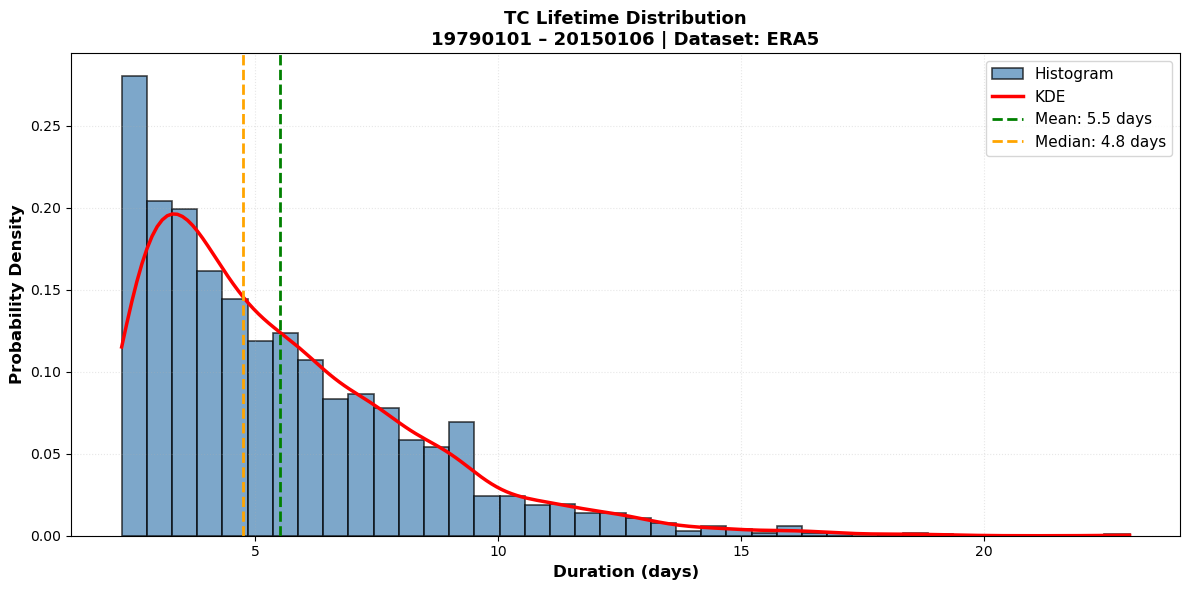

In [14]:
# Duration distribution
plot_tc_duration_distribution(tc_data, config)

Computing TC duration by category from memory...
Using data from memory (fast)

TC count per category:
  Cat 0: 29 storms, mean duration: 3.5 days
  Cat 1: 1183 storms, mean duration: 4.2 days
  Cat 2: 821 storms, mean duration: 6.0 days
  Cat 3: 344 storms, mean duration: 7.7 days
  Cat 4: 100 storms, mean duration: 9.1 days
  Cat 5: 7 storms, mean duration: 7.9 days
✓ Normalized duration histogram saved: /work/users/mccorda/tc_analysis2/Figures/tc_duration_normalized_by_category_ERA5_era5_19790101_20150106.pdf


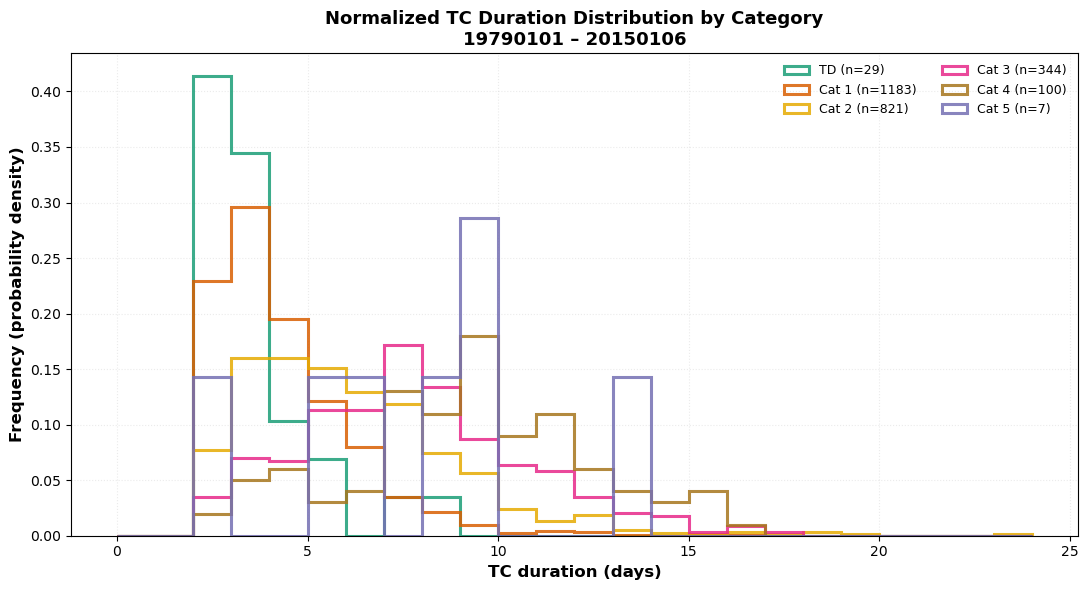

In [13]:
# Duration by category (normalized)
plot_tc_duration_by_category(tc_data, config)

Computing basin frequencies from memory...
Using data from memory (fast)
Period: 1979-2014 (36 years)

Annual frequencies (storms/year):
  NH total: 41.2
  SH total: 24.2
    North Atlantic: 8.4
    East Pacific: 8.2
    West Pacific: 22.2
    North Indian: 2.4
    South Indian: 14.5
    South Pacific: 9.8
✓ Doughnut chart saved: /work/users/mccorda/tc_analysis2/Figures/tc_doughnut_frequency_ERA5_era5_19790101_20150106.pdf


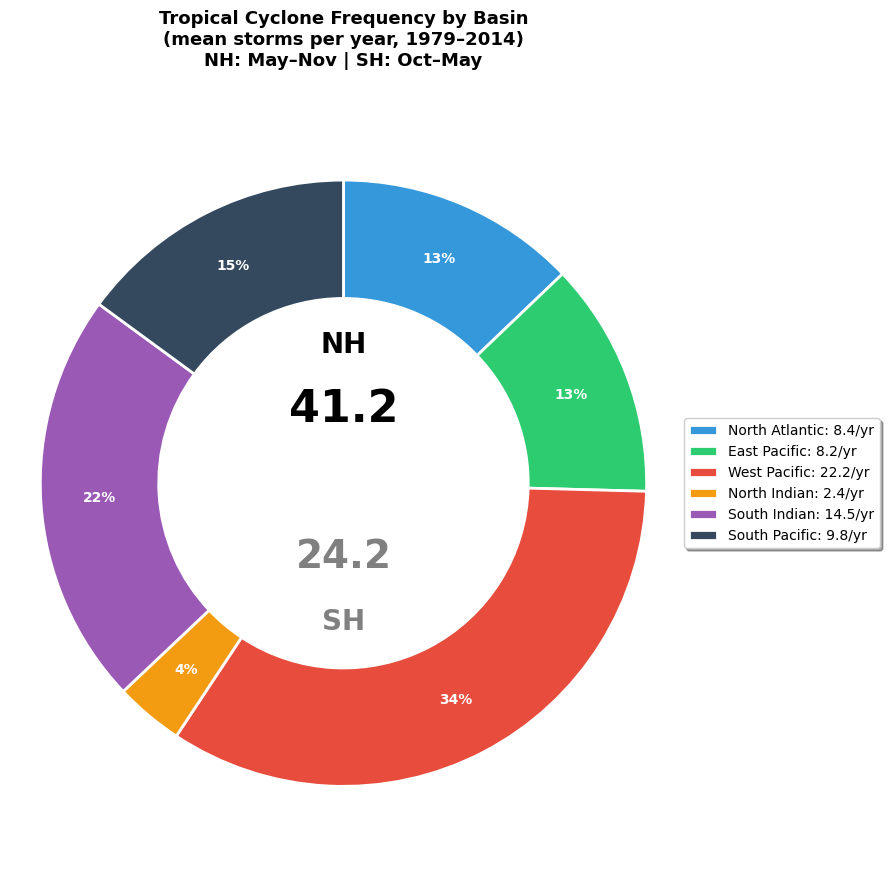


COMPARISON WITH ROBERTS ET AL. (2020)
Basin                This study         Roberts et al.     Difference     
----------------------------------------------------------------------
North Atlantic                    8.4             12.5     -4.1 (-33%)
East Pacific                      8.2             16.0     -7.8 (-49%)
West Pacific                     22.2             25.0     -2.8 (-11%)
North Indian                      2.4              5.5     -3.1 (-57%)
South Indian                     14.5             10.0      4.5 (+45%)
South Pacific                     9.8              4.5      5.3 (+117%)
----------------------------------------------------------------------
NH Total                         41.2             59.0    -17.8 (-30%)
SH Total                         24.2             14.5      9.8 (+67%)
✓ Comparison chart saved: /work/users/mccorda/tc_analysis2/Figures/tc_frequency_comparison_ERA5_era5_19790101_20150106.pdf


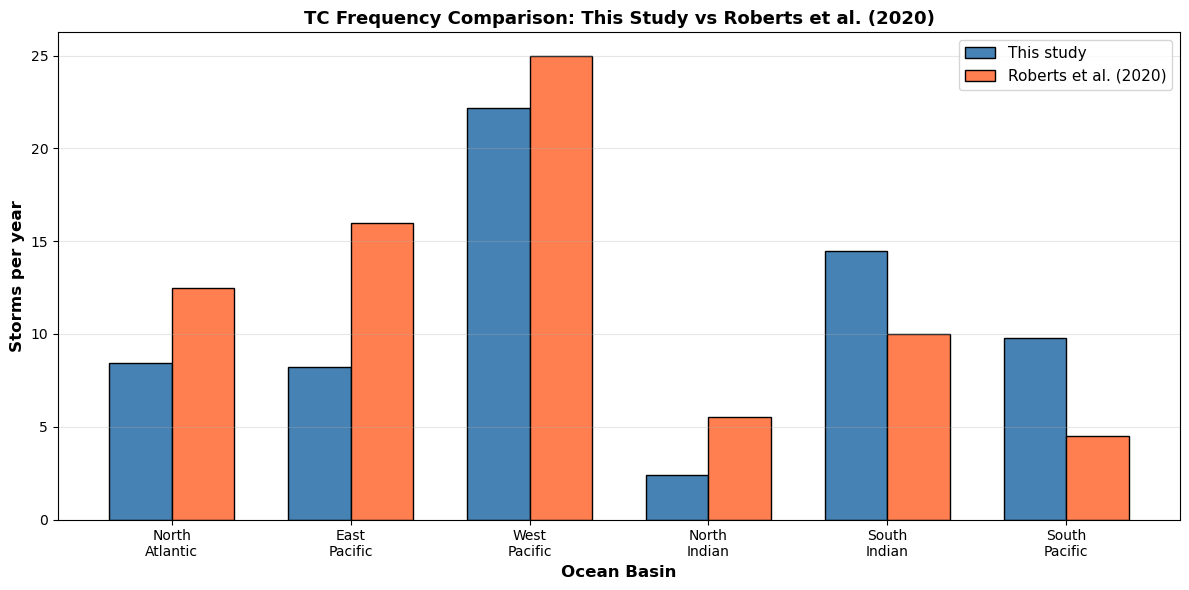

✓ Basin analysis complete!


In [12]:
# Basin doughnut + comparison
plot_tc_basin_doughnut(tc_data, config)

In [ ]:
# ============================================================================
# STEP PRELIMINARE: REGRIDDA ERA5 A r100 
# ============================================================================

import xarray as xr
import xesmf as xe  # oppure usi CDO
from glob import glob

print("="*80)
print("REGRIDDING ERA5 TO r100")
print("="*80)

# Directory input (ERA5 nativo)
era5_dir = "/home/mccorda/work/data/"

# Directory output (ERA5 @ r100)
r100_dir = "/work/users/mccorda/tc_analysis2/data_r100/"
os.makedirs(r100_dir, exist_ok=True)

# Griglia target r100 (1° x 1°, 360x180 punti)
target_grid = xr.Dataset({
    'lat': (['lat'], np.arange(-89.5, 90, 1.0)),
    'lon': (['lon'], np.arange(0.5, 360, 1.0))
})

years = range(1979, 2015)

for year in years:
    print(f"\nProcessing {year}...")
    
    # File input
    u_in = f"{era5_dir}ERA5_10m_u_component_of_wind_6hr_{year}.nc"
    v_in = f"{era5_dir}ERA5_10m_v_component_of_wind_6hr_{year}.nc"
    msl_in = f"{era5_dir}ERA5_mean_sea_level_pressure_6hr_{year}.nc"
    
    # File output
    u_out = f"{r100_dir}ERA5_u10_r100_{year}.nc"
    v_out = f"{r100_dir}ERA5_v10_r100_{year}.nc"
    msl_out = f"{r100_dir}ERA5_msl_r100_{year}.nc"
    
    # Skip se già fatto
    if all(os.path.exists(f) for f in [u_out, v_out, msl_out]):
        print(f"  Already regridded, skipping")
        continue
    
    # Regridda u10
    if not os.path.exists(u_out):
        print(f"  Regridding u10...")
        ds_u = xr.open_dataset(u_in)
        ds_u = ds_u.rename({'latitude': 'lat', 'longitude': 'lon', 'valid_time': 'time'})
        
        regridder = xe.Regridder(ds_u, target_grid, 'bilinear')
        ds_u_r100 = regridder(ds_u)
        
        ds_u_r100.to_netcdf(u_out)
        print(f"    Saved: {u_out}")
    
    # Regridda v10
    if not os.path.exists(v_out):
        print(f"  Regridding v10...")
        ds_v = xr.open_dataset(v_in)
        ds_v = ds_v.rename({'latitude': 'lat', 'longitude': 'lon', 'valid_time': 'time'})
        
        regridder = xe.Regridder(ds_v, target_grid, 'bilinear')
        ds_v_r100 = regridder(ds_v)
        
        ds_v_r100.to_netcdf(v_out)
        print(f"    Saved: {v_out}")
    
    # Regridda msl
    if not os.path.exists(msl_out):
        print(f"  Regridding msl...")
        ds_msl = xr.open_dataset(msl_in)
        ds_msl = ds_msl.rename({'latitude': 'lat', 'longitude': 'lon', 'valid_time': 'time'})
        
        regridder = xe.Regridder(ds_msl, target_grid, 'bilinear')
        ds_msl_r100 = regridder(ds_msl)
        
        ds_msl_r100.to_netcdf(msl_out)
        print(f"    Saved: {msl_out}")

print("\n✓ Regridding complete!")

In [ ]:
# ============================================================================
# ESTRAZIONE PARAMETRI DINAMICI E ENERGETICI DEI TCs
# Usando NodeFileCompose (metodo Bourdin et al. 2022, 2024)
# ============================================================================

import subprocess
import os
import pandas as pd
import numpy as np
import xarray as xr
from glob import glob
from datetime import datetime

# Usa la tua funzione già definita
#category_from_slp_pa(slp_pa):


def category_from_wind_kt(wind_kt):
    """Convert wind speed in knots to Saffir-Simpson category."""
    if wind_kt < 34:
        return 0  # TD
    elif wind_kt < 64:
        return 1  # Cat 1
    elif wind_kt < 83:
        return 2  # Cat 2
    elif wind_kt < 96:
        return 3  # Cat 3
    elif wind_kt < 113:
        return 4  # Cat 4
    else:
        return 5  # Cat 5

# ============================================================================
# 1. CONFIGURAZIONE
# ============================================================================

tracks_file = "/work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19790101_20150106_filtered_STJ_Bourdin250_monthly.txt"
# Directory con dati regriddati
r100_dir = "/work/users/mccorda/tc_analysis3/data_r100/"
output_dir = "/work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/"
os.makedirs(output_dir, exist_ok=True)

print("="*80)
print("ESTRAZIONE PARAMETRI DINAMICI E ENERGETICI DEI TCs")
print("Metodo: NodeFileCompose (Bourdin et al.)")
print("="*80)
print(f"Tracks: {tracks_file}")
print(f"Data: {data_dir}")
print(f"Output: {output_dir}")

# ============================================================================
# 2. CREA DATA LIST
# ============================================================================

years = range(1979, 2015)

available_years = []

# Crea data list
data_list = []
for year in range(1979, 2015):
    u = f"{r100_dir}ERA5_u10_r100_{year}.nc"
    v = f"{r100_dir}ERA5_v10_r100_{year}.nc"
    msl = f"{r100_dir}ERA5_msl_r100_{year}.nc"
    
    if all(os.path.exists(f) for f in [u, v, msl]):
        data_list.append(f"{u};{v};{msl}")

data_list_file = os.path.join(output_dir, "data_list_r100.txt")
with open(data_list_file, 'w') as f:
    f.write('\n'.join(data_list))

print(f"✓ Data list created: {len(data_list)} years")

# ============================================================================
# 3. PREPARA FILE TRACCE CON HEADER (se necessario)
# ============================================================================

print("\n" + "="*80)
print("PREPARING TRACK FILE")
print("="*80)

# Verifica se il file ha header
with open(tracks_file, 'r') as f:
    first_line = f.readline().strip()

# Se la prima riga inizia con un numero, NON ha header
if first_line[0].isdigit():
    print("Track file has no header - adding one...")
    
    # Crea versione con header
    tracks_with_header = os.path.join(output_dir, "tracks_with_header.txt")
    
    with open(tracks_file, 'r') as fin, open(tracks_with_header, 'w') as fout:
        # Scrivi header
        fout.write("track_id\tyear\tmonth\tday\thour\ti\tj\tlon\tlat\tslp\twind\tzs\n")
        # Copia tutti i dati
        fout.write(fin.read())
    
    tracks_to_use = tracks_with_header
    print(f"✓ Created: {tracks_with_header}")
else:
    print("Track file already has header")
    tracks_to_use = tracks_file

# Mostra prime righe
print("\nFirst 3 lines:")
with open(tracks_to_use, 'r') as f:
    for i in range(3):
        print(f"  {f.readline().strip()}")

# ============================================================================
# 4. ESEGUI NODEFILECOMPOSE
# ============================================================================

print("\n" + "="*80)
print("RUNNING NODEFILECOMPOSE")
print("="*80)

composed_file = os.path.join(output_dir, "tc_composed_data.nc")

# NodeFileCompose
command = [
    "NodeFileCompose",
    "--in_data_list", data_list_file,
    "--in_nodefile", tracks_to_use,
    "--out", composed_file,
    "--in_fmt", "lon,lat",
    "--var", "u10",
    "--var", "v10",
    "--var", "msl",
    "--dx", "2.0",                    # 2° su griglia r100 = ~2 celle
    "--timefilter", "6hr",
    "--latname", "lat",               # Dopo regrid sono lat/lon
    "--lonname", "lon",
    "--timename", "time",             # Dopo regrid è time
    "--regional"
]
print("Configuration:")
print(f"  Input format: lon,lat (geographic coordinates)")
print(f"  Extraction radius: 2.0° (≈ 222 km)")
print("\nUsing REGRIDDED data at r100 resolution (~100 km)")
print("This ensures consistency with track detection")
print(f"  Coordinate names: latitude, longitude")
print(f"  Time variable: valid_time")
print(f"\nCommand:")

try:
    result = subprocess.run(
        command, 
        capture_output=True, 
        text=True, 
        check=True,
        timeout=3600  # 1 ora timeout
    )
    print("✓ NodeFileCompose completed successfully")
    
    if result.stdout:
        print("\nOutput (first 800 chars):")
        print(result.stdout[:800])
        
except subprocess.TimeoutExpired:
    print("ERROR: Command timed out after 1 hour")
    raise
    
except subprocess.CalledProcessError as e:
    print("ERROR: NodeFileCompose failed")
    print(f"Return code: {e.returncode}")
    print("\n--- STDERR ---")
    print(e.stderr)
    print("\n--- STDOUT ---")
    print(e.stdout)
    
    # Debug info
    print("\n--- DEBUG INFO ---")
    print("Checking if files exist:")
    print(f"  Track file: {os.path.exists(tracks_to_use)}")
    print(f"  Data list: {os.path.exists(data_list_file)}")
    
    print("\nFirst data file from list:")
    with open(data_list_file, 'r') as f:
        first_data = f.readline().strip().split(';')
        for fname in first_data:
            print(f"  {fname}: {os.path.exists(fname)}")
    
    raise

# Verifica output
if os.path.exists(composed_file):
    file_size_mb = os.path.getsize(composed_file) / (1024**2)
    print(f"\n✓ Output file created: {composed_file}")
    print(f"  Size: {file_size_mb:.1f} MB")
else:
    print("\nWARNING: Output file not created!")

# ============================================================================
# 4. LEGGI DATI COMPOSTI
# ============================================================================

print("\n" + "="*80)
print("LOADING COMPOSED DATA")
print("="*80)

ds = xr.open_dataset(composed_file)
print(f"✓ Loaded: {dict(ds.dims)}")

# ============================================================================
# 5. CALCOLA PARAMETRI PER OGNI TIMESTEP
# ============================================================================

print("\n" + "="*80)
print("COMPUTING DYNAMIC PARAMETERS")
print("="*80)

n_obs = len(ds.grid_x)
print(f"Processing {n_obs} TC observations...")

# Parametri fisici
RHO_AIR = 1.15  # kg/m³
GRID_SPACING_DEG = 0.25  # ERA5 risoluzione
GRID_SPACING_M = GRID_SPACING_DEG * 111000  # metri
CELL_AREA_M2 = GRID_SPACING_M ** 2

timestep_data = []

for i in range(n_obs):
    if i % 1000 == 0:
        print(f"  Progress: {i}/{n_obs}")
    
    # Estrai venti (m/s)
    u = ds['u10'].isel(ncol=i).values
    v = ds['v10'].isel(ncol=i).values
    wind_speed = np.sqrt(u**2 + v**2)
    
    # Estrai pressione (Pa)
    msl_pa = ds['msl'].isel(ncol=i).values
    
    # === VENTO MASSIMO (m/s) ===
    max_wind_ms = np.nanmax(wind_speed)
    max_wind_kt = max_wind_ms * 1.94384  # Per ACE tradizionale
    
    # Vento medio
    mean_wind_ms = np.nanmean(wind_speed)
    
    # === PRESSIONE ===
    min_pressure_pa = np.nanmin(msl_pa)
    min_pressure_hpa = min_pressure_pa / 100.0
    mean_pressure_pa = np.nanmean(msl_pa)
    mean_pressure_hpa = mean_pressure_pa / 100.0
    
    # =========================================================================
    # ACE - ENTRAMBE LE VERSIONI
    # =========================================================================
    # Versione tradizionale NOAA (kt², normalizzato × 10⁻⁴)
    ace_kt2 = max_wind_kt ** 2
    
    # Versione SI (m²/s²)
    ace_si = max_wind_ms ** 2
    
    # =========================================================================
    # PDI - Power Dissipation Index (Emanuel 2005)
    # =========================================================================
    # Unità: m³/s³ (potenza per unità di massa)
    # Timestep = 6 ore
    pdi_si = (max_wind_ms ** 3) * 6 * 3600  # 6 ore in secondi
    
    # =========================================================================
    # IKE - Integrated Kinetic Energy (Powell & Reinhold 2007)
    # =========================================================================
    # Unità: Joules (J)
    # IKE = (1/2) * rho * sum(V²) * cell_area
    ike_joules = 0.5 * RHO_AIR * np.nansum(wind_speed**2) * CELL_AREA_M2
    ike_TJ = ike_joules / 1e12  # Converti in terajoule per leggibilità
    
    timestep_data.append({
        'obs_index': i,
        'max_wind_ms': max_wind_ms,
        'max_wind_kt': max_wind_kt,
        'mean_wind_ms': mean_wind_ms,
        'min_pressure_hPa': min_pressure_hpa,
        'mean_pressure_hPa': mean_pressure_hpa,
        'pressure_deficit_hPa': mean_pressure_hpa - min_pressure_hpa,
        # ACE - entrambe versioni
        'ace_component_kt2': ace_kt2,        # kt² (NOAA)
        'ace_component_si': ace_si,          # m²/s² (SI)
        # PDI - solo SI
        'pdi_component_si': pdi_si,          # m³/s³·s
        # IKE - solo SI
        'ike_joules': ike_joules,            # J
        'ike_TJ': ike_TJ                     # TJ
    })

df_params = pd.DataFrame(timestep_data)
print(f"✓ Computed parameters for {len(df_params)} observations")

# ============================================================================
# 7. CALCOLA LIFETIME STATISTICS
# ============================================================================

print("\n" + "="*80)
print("COMPUTING LIFETIME STATISTICS")
print("="*80)

tc_lifetime = df_all.groupby('track_id').agg({
    'max_wind_ms': 'max',
    'max_wind_kt': 'max',
    'mean_wind_ms': 'mean',
    'min_pressure_hPa': 'min',
    'pressure_deficit_hPa': 'max',
    # ACE - entrambe
    'ace_component_kt2': 'sum',
    'ace_component_si': 'sum',
    # PDI - SI
    'pdi_component_si': 'sum',
    # IKE - SI
    'ike_joules': 'sum',
    'ike_TJ': 'sum',
    'lon': ['first', 'last', 'count'],
    'lat': ['first', 'last'],
    'year': 'first',
    'month': 'first',
    'slp': 'min'
}).reset_index()

# Flatten
tc_lifetime.columns = ['_'.join(str(c)).strip('_') for c in tc_lifetime.columns]

# Rinomina
tc_lifetime = tc_lifetime.rename(columns={
    'track_id': 'track_id',
    'max_wind_ms_max': 'LMI_ms',
    'max_wind_kt_max': 'LMI_kt',
    'mean_wind_ms_mean': 'mean_wind_ms',
    'min_pressure_hPa_min': 'min_pressure_hPa',
    'pressure_deficit_hPa_max': 'max_deficit_hPa',
    # ACE
    'ace_component_kt2_sum': 'ACE_kt2',              # kt² totale
    'ace_component_si_sum': 'ACE_m2s2',              # m²/s² totale
    # PDI
    'pdi_component_si_sum': 'PDI_m3s3',              # m³/s³·s totale
    # IKE
    'ike_joules_sum': 'IKE_joules',                  # J totale
    'ike_TJ_sum': 'IKE_TJ',                          # TJ totale
    'lon_first': 'genesis_lon',
    'lon_last': 'lysis_lon',
    'lon_count': 'n_timesteps',
    'lat_first': 'genesis_lat',
    'lat_last': 'lysis_lat',
    'year_first': 'year',
    'month_first': 'month',
    'slp_min': 'min_slp_Pa'
})

# Durata
tc_lifetime['duration_hours'] = tc_lifetime['n_timesteps'] * 6
tc_lifetime['duration_days'] = tc_lifetime['duration_hours'] / 24

# ACE normalizzato (NOAA standard: × 10⁻⁴)
tc_lifetime['ACE_NOAA'] = tc_lifetime['ACE_kt2'] * 1e-4

# PDI in unità più leggibili (petawatt·second, PW·s)
tc_lifetime['PDI_PWs'] = tc_lifetime['PDI_m3s3'] * RHO_AIR / 1e15

# Categorie
tc_lifetime['category_pressure'] = tc_lifetime['min_slp_Pa'].apply(category_from_slp_pa)
tc_lifetime['category_wind'] = tc_lifetime['LMI_kt'].apply(category_from_wind_kt)

print(f"✓ Computed lifetime stats for {len(tc_lifetime)} TCs")

# ============================================================================
# 8. STATISTICHE RIASSUNTIVE
# ============================================================================

print("\n" + "="*80)
print("SUMMARY STATISTICS (SI units + traditional ACE)")
print("="*80)

print("\n--- INTENSITÀ (SI) ---")
print(f"LMI (m/s):   mean={tc_lifetime['LMI_ms'].mean():.2f}, "
      f"median={tc_lifetime['LMI_ms'].median():.2f}, max={tc_lifetime['LMI_ms'].max():.2f}")
print(f"LMI (kt):    mean={tc_lifetime['LMI_kt'].mean():.1f}, "
      f"median={tc_lifetime['LMI_kt'].median():.1f}, max={tc_lifetime['LMI_kt'].max():.1f}")
print(f"Min P (hPa): mean={tc_lifetime['min_pressure_hPa'].mean():.1f}, "
      f"min={tc_lifetime['min_pressure_hPa'].min():.1f}")

print("\n--- ACE (entrambe le convenzioni) ---")
print(f"ACE tradizionale NOAA (×10⁴ kt²):")
print(f"  Total season:  {tc_lifetime['ACE_NOAA'].sum():>10.1f}")
print(f"  Mean per TC:   {tc_lifetime['ACE_NOAA'].mean():>10.2f}")
print(f"  Max per TC:    {tc_lifetime['ACE_NOAA'].max():>10.2f}")

print(f"\nACE in SI (m²/s²):")
print(f"  Total season:  {tc_lifetime['ACE_m2s2'].sum():>12.1f} m²/s²")
print(f"  Mean per TC:   {tc_lifetime['ACE_m2s2'].mean():>12.1f} m²/s²")
print(f"  Max per TC:    {tc_lifetime['ACE_m2s2'].max():>12.1f} m²/s²")

print("\n--- PDI in SI (m³/s³·s = kg·m²/s²) ---")
print(f"  Total:   {tc_lifetime['PDI_m3s3'].sum():>12.2e} m³/s³·s")
print(f"  Mean:    {tc_lifetime['PDI_m3s3'].mean():>12.2e} m³/s³·s")
print(f"  Max:     {tc_lifetime['PDI_m3s3'].max():>12.2e} m³/s³·s")

print(f"\nPDI leggibile (PW·s = 10¹⁵ W·s):")
print(f"  Total:   {tc_lifetime['PDI_PWs'].sum():>10.2f} PW·s")
print(f"  Mean:    {tc_lifetime['PDI_PWs'].mean():>10.2f} PW·s")
print(f"  Max:     {tc_lifetime['PDI_PWs'].max():>10.2f} PW·s")

print("\n--- IKE in SI (Joules) ---")
print(f"  Total:   {tc_lifetime['IKE_joules'].sum():>12.2e} J")
print(f"  Mean:    {tc_lifetime['IKE_joules'].mean():>12.2e} J")
print(f"  Max:     {tc_lifetime['IKE_joules'].max():>12.2e} J")

print(f"\nIKE leggibile (TJ = 10¹² J):")
print(f"  Total:   {tc_lifetime['IKE_TJ'].sum():>10.1f} TJ")
print(f"  Mean:    {tc_lifetime['IKE_TJ'].mean():>10.2f} TJ")
print(f"  Max:     {tc_lifetime['IKE_TJ'].max():>10.2f} TJ")

print("\n--- DURATA ---")
print(f"Mean: {tc_lifetime['duration_days'].mean():.1f} days")
print(f"Max:  {tc_lifetime['duration_days'].max():.1f} days")

# ============================================================================
# 9. SALVA CSV
# ============================================================================

output_timesteps = os.path.join(output_dir, "tc_all_timesteps_energetics.csv")
df_all.to_csv(output_timesteps, index=False)

output_lifetime = os.path.join(output_dir, "tc_lifetime_energetics.csv")
tc_lifetime.to_csv(output_lifetime, index=False)

print("\n" + "="*80)
print("FILE SALVATI")
print("="*80)
print(f"✓ Timesteps: {output_timesteps}")
print(f"✓ Lifetime:  {output_lifetime}")

print("\n" + "="*80)
print("COLONNE NEL FILE tc_lifetime_energetics.csv")
print("="*80)
print("\nIntensità:")
print("  - LMI_ms: Lifetime Max Intensity (m/s)")
print("  - LMI_kt: Lifetime Max Intensity (kt)")
print("  - min_pressure_hPa: Minimum pressure (hPa)")

print("\nIndici energetici (ACE - entrambe):")
print("  - ACE_NOAA: NOAA convention (×10⁴ kt²) - per confronto con IBTrACS")
print("  - ACE_m2s2: SI units (m²/s²) - per pubblicazioni scientifiche")

print("\nIndici energetici (SI):")
print("  - PDI_m3s3: Power Dissipation Index (m³/s³·s)")
print("  - PDI_PWs: PDI leggibile (petawatt·second)")
print("  - IKE_joules: Integrated Kinetic Energy (J)")
print("  - IKE_TJ: IKE leggibile (terajoule)")

print("\nAltro:")
print("  - duration_days: Durata (giorni)")
print("  - category_pressure, category_wind: Categorie Saffir-Simpson")

print("\n" + "="*80)
print("FORMULE UTILIZZATE")
print("="*80)
print("ACE_NOAA = Σ(Vmax_kt²) × 10⁻⁴  [ogni 6h]")
print("ACE_SI   = Σ(Vmax_m/s²)        [ogni 6h]")
print("PDI      = Σ(Vmax³ × 6h)       [m³/s³·s]")
print("IKE      = Σ(½ρ∫∫V²dA)         [J]")
print("\nRiferimenti:")
print("- ACE: Bell et al. (2000), Climate Assessment")
print("- PDI: Emanuel (2005), Nature 436:686-688")
print("- IKE: Powell & Reinhold (2007), Mon. Wea. Rev. 135:3965-3975")

In [12]:
client.shutdown()
cluster.close()